# Manual validation of the predicted cell types

**Developed by:** Anna Maguza\
**Affiliation:** Faculty of Medicine, Würzburg University\
**Creation date:** 23rd December 2024\
**Last modified date:** 23rd December 2024

This notebook outlines the process of validation of predicted by `scVI - scANVI` pipeline cell type annotations. We will evaluate `scANVI` classificator confidence and also validate the predicted annotation with markers.

Then we will generate multiple plots for the dataset description. 

## Import packages

In [1]:
import numpy as np
import scanpy as sc
import anndata
import pandas as pd
import plotnine as p
#from pywaffle import Waffle
import matplotlib.pyplot as plt
import seaborn as sns

import json
from datetime import datetime
import scipy.sparse

## Setup working environment

In [2]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi = 180, color_map = 'magma_r', dpi_save = 300, vector_friendly = True, format = 'svg')

In [3]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')

In [4]:
timestamp

'06022025_105010'

## Upload data

In [5]:
adata = sc.read_h5ad('/Users/annamaguza/Desktop/data/gut_data/gut_hs_all_datasets_epithelial_annotated_AM_29012025_122312_raw.h5ad')

In [85]:
adata = sc.read_h5ad('/Users/annamaguza/Desktop/data/gut_data/gut_hs_all_datasets_scVI_scANVI_celltypes_AM_10012025_100142_raw.h5ad')
adata

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


AnnData object with n_obs × n_vars = 402343 × 43704
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoc

## Validate confidence score and markers expression

In [6]:
adata_log = adata.copy()
sc.pp.normalize_total(adata_log, target_sum=1e6, exclude_highly_expressed=True)
sc.pp.log1p(adata_log)

normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['PLA2G2A', 'GUCA2B', 'GUCA2A', 'CLCA1', 'ATP1A1-AS1', 'REG4', 'S100A6', 'ITLN1', 'ITLN2', 'APOA2', 'PIGR', 'REG1A', 'REG3A', 'FABP1', 'GCG', 'CRYBA2', 'GHRL', 'CCK', 'RBP2', 'SST', 'ENSG00000286848', 'JCHAIN', 'GC', 'ALB', 'AFP', 'RPL34', 'CCDC152', 'ATG10', 'SPINK1', 'FABP6', 'ENSG00000271581', 'MLN', 'ENSG00000287089', 'CLPS', 'AGR2', 'RPL30-AS1', 'RPS6', 'SPINK4', 'RPL12', 'LCN2', 'LCN15', 'VIM-AS1', 'ADIRF-AS1', 'SHLD2', 'INS', 'BEST1', 'FTH1', 'TALAM1', 'ENSG00000285513', 'APOA4', 'APOC3', 'APOA1', 'APOA1-AS', 'GAPDH', 'ENSG00000269968', 'MRPS35-DT', 'LYZ', 'ENSG00000257764', 'NTS', 'TPT1', 'ENSG00000273149', 'CKB', 'PHGR1', 'ENSG00000290038', 'ENSG00000290010', 'ZG16', 'MT2A', 'MT1G', 'MT1H', 'GAST', 'PYY', 'GIP', 'TTR', 'ENSG00000267598', 'YIF1B', 'RPS19', 'FTL', 'TFF3', 'TFF2', 'TFF1', 'IGLC2', 'IGLC3', 'TMSB4X', 'PCSK1N', 'MT-RNR1', 'MT-RNR2', 'MT-CO1'

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=["C_scANVI", "confidence_score"], ncols=4, color_map = 'magma', frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/scANVI_confidence_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ B cells 

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata_log,color=["C_scANVI", 'CD19', 'MS4A1', 'CD79A', 'CD79B', 'CD22'], ncols=3, color_map = 'magma_r', frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/B_cells_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ Endothelial cells 

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata_log,color=["C_scANVI", 'PECAM1', 'CDH5', 'VWF', 'CLDN5', 'TEK', 'KDR'], ncols=4, color_map = 'magma_r', frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/Endothelial_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ Epithelial cells 

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata_log,color=["C_scANVI", 'EPCAM', 'KRT8', 'KRT18', 'KRT19', 'CDH1', 'CLDN4'], ncols=4, color_map = 'magma_r', frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/Epithelial_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ Mesenchymal cells 

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata_log,color=["C_scANVI", 'COL1A1', 'COL3A1', 'VIM', 'DCN', 'FAP', 'THY1'], ncols=4, color_map = 'magma_r', frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/Mesenchymal_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ Myeloid cells 

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata_log,color=["C_scANVI", 'CD14', 'CD68', 'CD163', 'CSF1R', 'ITGAM', 'ITGAM', 'CD72', 'CD128', 'FOLR2', 'CD74'], ncols=4, color_map = 'magma_r', frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/Myeloid_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ Neuronal cells 

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata_log,color=["C_scANVI", 'MAP2', 'RBFOX3', 'TUBB3', 'ENO2', 'SYP', 'SNAP25'], ncols=4, color_map = 'magma_r', frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/Neuronal_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ Plasma cells 

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata_log,color=["C_scANVI", 'SDC1', 'IGHG1', 'MZB1', 'XBP1', 'PRDM1'], ncols=4, color_map = 'magma_r', frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/Plasma_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ Red blood cells

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata_log,color=["C_scANVI", 'HBA1', 'HBA2', 'HBB', 'ALAS2', 'GYPA', 'SLC4A1'], ncols=4, color_map = 'magma_r', frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/Red_blood_cells_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ T cells

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata_log,color=["C_scANVI", 'CD3D', 'CD3E', 'CD3G', 'CD4', 'CD8A', 'CD2'], ncols=4, color_map = 'magma_r', frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/T_cells_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

+ dot plot

In [ ]:
validation_markers = {
    'B cells': ['CD19', 'MS4A1', 'CD79A', 'CD79B', 'CD22'],
    
    'Endothelial': ['PECAM1', 'CDH5', 'VWF', 'CLDN5', 'TEK', 'KDR'],
    
    'Epithelial': ['EPCAM', 'KRT8', 'KRT18', 'KRT19', 'CDH1', 'CLDN4'],
    
    'Mesenchymal': ['COL1A1', 'COL3A1', 'VIM', 'DCN', 'FAP', 'THY1'],
    
    'Myeloid': ['CD14', 'CD68', 'CD163', 'CSF1R', 'ITGAM'],
    
    'Neuronal': ['MAP2', 'RBFOX3', 'TUBB3', 'ENO2', 'SYP', 'SNAP25'],
    
    'Plasma cells': ['SDC1', 'IGHG1', 'MZB1', 'XBP1', 'PRDM1'],
    
    'Red blood cells': ['HBA1', 'HBA2', 'HBB', 'ALAS2', 'GYPA', 'SLC4A1'],
    
    'T cells': ['CD3D', 'CD3E', 'CD3G', 'CD4', 'CD8A', 'CD2']
}

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.dotplot(adata_log, 
                 var_names=validation_markers,
                 groupby='C_scANVI',  # adjust if your column name is different
                 dendrogram=True,
                 standard_scale='var',  # standardize expression across genes
                 figsize=(15, 8))
    plt.savefig(f"integration_of_remapped_data/plots/dotplot_markers_{timestamp}.png", bbox_inches="tight")
    plt.show()

## Generate plots for datasets description

* Stacked barplots

In [ ]:
observations = ['age_group', 'organism_part', 'sex', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 
                'library_preparation_protocol', 'full_age', 'immunophenotype', 'gestational_age', 'growth_condition', 'developmental_stage']

In [ ]:
for val in observations:
    props = pd.crosstab(
        adata.obs[val],
        adata.obs['C_scANVI'],
        normalize='index'
    ) * 100

    ax = props.plot(kind='bar', 
                   stacked=True,
                   figsize=(6, 6))
    
    plt.xlabel(val)
    plt.ylabel('Percentage')
    plt.legend(title='Cell Types', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    plt.savefig(f"integration_of_remapped_data/plots/Cell_Type_Distribution_Across_{val}_{timestamp}.png", bbox_inches="tight")

In [ ]:
props = pd.crosstab(
        adata.obs['organism_part'],
        adata.obs['C_scANVI'],
        normalize='index'
    ) * 100

    # Create stacked barplot
ax = props.plot(kind='bar', 
                   stacked=True,
                   figsize=(12, 6))
    
plt.xlabel('Organism part')
plt.ylabel('Percentage')
plt.legend(title='Cell Types', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"integration_of_remapped_data/plots/Cell_Type_Distribution_Across_organism_part_{timestamp}.png", bbox_inches="tight")

In [ ]:
props = pd.crosstab(
        adata.obs['full_age'],
        adata.obs['C_scANVI'],
        normalize='index'
    ) * 100

    # Create stacked barplot
ax = props.plot(kind='bar', 
                   stacked=True,
                   figsize=(20, 6))
    
plt.xlabel('full_age')
plt.ylabel('Percentage')
plt.legend(title='Cell Types', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"integration_of_remapped_data/plots/Cell_Type_Distribution_Across_full_age_{timestamp}.png", bbox_inches="tight")

In [ ]:
props = pd.crosstab(
        adata.obs['gestational_age'],
        adata.obs['C_scANVI'],
        normalize='index'
    ) * 100

    # Create stacked barplot
ax = props.plot(kind='bar', 
                   stacked=True,
                   figsize=(10, 6))
    
plt.xlabel('gestational_age')
plt.ylabel('Percentage')
plt.legend(title='Cell Types', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"integration_of_remapped_data/plots/Cell_Type_Distribution_Across_gestational_age_{timestamp}.png", bbox_inches="tight")

* Normal barplots

In [ ]:
for val in observations:  
    sample_counts = adata.obs[val].value_counts()

    plt.figure(figsize=(6, 6))
    ax = sns.barplot(x=sample_counts.index, 
                    y=sample_counts.values)
    
    plt.xticks(rotation=45, ha='right')
    plt.xlabel(val)
    plt.ylabel('Number of Cells')
    plt.title('Cells per Sample')
    plt.tight_layout()
    plt.savefig(f"integration_of_remapped_data/plots/number_of_cells_per_{val}_{timestamp}.png", bbox_inches="tight")


* Waffle plots

In [ ]:
observations = ['age_group', 'organism_part', 'Study_name', 'ArrayExpress_ID']

In [ ]:
color_list = ['#FF76CE',  # bright pink
                '#E9A8F2',  # light lavender
                '#94FFD8',  # mint green
                '#A3D8FF',  # light sky blue
                '#FFA27F',  # light coral
                '#982B1C',  # bricks color
                '#43766C',  #dark teal
                #'#759EB8',  #steel blue
                '#824670',  # deep purple
                '#ff4a46']  # bright red-orange

In [ ]:
# Create color dictionary for cell types
cell_types = adata.obs['C_scANVI'].unique()
color_dict = dict(zip(cell_types, color_list))

# Get cell counts for each age group
age_groups = []
for age in adata.obs['age_group'].unique():
    subset = adata[adata.obs['age_group'] == age]
    counts = subset.obs['C_scANVI'].value_counts().reset_index()
    counts.columns = ['Cell_State', 'Number_of_Cells']
    counts['age_group'] = age
    age_groups.append(counts)

# Create a figure with subplots for each age group
n_ages = len(adata.obs['age_group'].unique())

for idx, age_data in enumerate(age_groups, 1):
    # Get colors in the same order as cell types in counts
    plot_colors = [color_dict[cell_type] for cell_type in age_data['Cell_State']]
    
    fig = plt.figure(
        FigureClass=Waffle,
        rows=15,
        columns=70,
        values=age_data['Number_of_Cells'],
        labels=[f"{label} ({value})" for label, value in 
               zip(age_data['Cell_State'], age_data['Number_of_Cells'])],
        legend={'loc': 'upper left', 'bbox_to_anchor': (1, 1)},
        figsize=(12, 8),
        colors=plot_colors
    )
    plt.title(f"Age Group: {age_data['age_group'].iloc[0]}")
    plt.savefig(f"integration_of_remapped_data/plots/waffles/waffle_plot_age_group_{age_data['age_group'].iloc[0]}.png", 
                dpi=300, 
                bbox_inches='tight')
    plt.show()

In [ ]:
# Get cell counts for each age group
age_groups = []
for age in adata.obs['ArrayExpress_ID'].unique():
    subset = adata[adata.obs['ArrayExpress_ID'] == age]
    counts = subset.obs['C_scANVI'].value_counts().reset_index()
    counts.columns = ['Cell_type', 'Number_of_Cells']
    counts['ArrayExpress_ID'] = age
    age_groups.append(counts)

# Create a figure with subplots for each age group
n_ages = len(adata.obs['ArrayExpress_ID'].unique())

for idx, age_data in enumerate(age_groups, 1):
    # Get colors in the same order as cell types in counts
    plot_colors = [color_dict[cell_type] for cell_type in age_data['Cell_type']]
    
    fig = plt.figure(
        FigureClass=Waffle,
        rows=15,
        columns=70,
        values=age_data['Number_of_Cells'],
        labels=[f"{label} ({value})" for label, value in 
               zip(age_data['Cell_type'], age_data['Number_of_Cells'])],
        legend={'loc': 'upper left', 'bbox_to_anchor': (1, 1)},
        figsize=(12, 8),
        colors=plot_colors
    )
    plt.title(f"ArrayExpress_ID: {age_data['ArrayExpress_ID'].iloc[0]}")
    plt.savefig(f"integration_of_remapped_data/plots/waffles/waffle_plot_ArrayExpress_ID_{age_data['ArrayExpress_ID'].iloc[0]}.png", 
                dpi=300, 
                bbox_inches='tight')
    plt.show()

In [ ]:
# Get cell counts for each age group
age_groups = []
for age in adata.obs['Study_name'].unique():
    subset = adata[adata.obs['Study_name'] == age]
    counts = subset.obs['C_scANVI'].value_counts().reset_index()
    counts.columns = ['Cell_type', 'Number_of_Cells']
    counts['Study_name'] = age
    age_groups.append(counts)

# Create a figure with subplots for each age group
n_ages = len(adata.obs['Study_name'].unique())

for idx, age_data in enumerate(age_groups, 1):
    # Get colors in the same order as cell types in counts
    plot_colors = [color_dict[cell_type] for cell_type in age_data['Cell_type']]
    
    fig = plt.figure(
        FigureClass=Waffle,
        rows=15,
        columns=70,
        values=age_data['Number_of_Cells'],
        labels=[f"{label} ({value})" for label, value in 
               zip(age_data['Cell_type'], age_data['Number_of_Cells'])],
        legend={'loc': 'upper left', 'bbox_to_anchor': (1, 1)},
        figsize=(12, 8),
        colors=plot_colors
    )
    plt.title(f"Study_name: {age_data['Study_name'].iloc[0]}")
    plt.savefig(f"integration_of_remapped_data/plots/waffles/waffle_plot_Study_name_{age_data['Study_name'].iloc[0]}.png", 
                dpi=300, 
                bbox_inches='tight')
    plt.show()

In [ ]:
# Get cell counts for each age group
age_groups = []
for age in adata.obs['organism_part'].unique():
    subset = adata[adata.obs['organism_part'] == age]
    counts = subset.obs['C_scANVI'].value_counts().reset_index()
    counts.columns = ['Cell_type', 'Number_of_Cells']
    counts['organism_part'] = age
    age_groups.append(counts)

# Create a figure with subplots for each age group
n_ages = len(adata.obs['organism_part'].unique())

for idx, age_data in enumerate(age_groups, 1):
    # Get colors in the same order as cell types in counts
    plot_colors = [color_dict[cell_type] for cell_type in age_data['Cell_type']]
    
    fig = plt.figure(
        FigureClass=Waffle,
        rows=15,
        columns=70,
        values=age_data['Number_of_Cells'],
        labels=[f"{label} ({value})" for label, value in 
               zip(age_data['Cell_type'], age_data['Number_of_Cells'])],
        legend={'loc': 'upper left', 'bbox_to_anchor': (1, 1)},
        figsize=(12, 8),
        colors=plot_colors
    )
    plt.title(f"organism_part: {age_data['organism_part'].iloc[0]}")
    plt.savefig(f"integration_of_remapped_data/plots/waffles/waffle_plot_organism_part_{age_data['organism_part'].iloc[0]}.png", 
                dpi=300, 
                bbox_inches='tight')
    plt.show()

### Supplelementary figure 1A

In [87]:
adata = adata[adata.obs['predicted_doublets'] != 'True']

In [88]:
adata = adata[adata.obs['C_scANVI'] != 'Red blood cells'].copy()

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


In [89]:
cell_counts = adata.obs['sample_id'].value_counts()
samples_to_remove = cell_counts[cell_counts < 10].index
adata = adata[~adata.obs['sample_id'].isin(samples_to_remove)].copy()

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


In [9]:
adata.obs['age_group'].value_counts()

age_group
second trimester      169491
first trimester       148222
adult                  32535
cell culture model     22305
child stage            16741
Name: count, dtype: int64

In [33]:
adata_filtered = adata[adata.obs['age_group'].isin(['adult', 'child stage'])].copy()
adata_filtered

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


AnnData object with n_obs × n_vars = 22306 × 43704
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoco

In [34]:
adata_filtered.obs['full_age'].value_counts()

full_age
15.0 week    6609
8.5 week     5749
20.3 week    3949
7.4 week     3126
8.4 week     2873
Name: count, dtype: int64

In [ ]:
num_samples = adata_filtered.obs['sample_id'].nunique()
num_samples

### Figure 1A

In [61]:
adata_filtered = adata[adata.obs['age_group'].isin(['adult', 'child stage'])].copy()

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


In [62]:
samples_per_organism_part = adata_filtered.obs.groupby('organism_part')['sample_id'].nunique()
samples_per_organism_part

/var/folders/kr/nd4y_1_s34n42lrht8wdh4cr0000gq/T/ipykernel_12243/3169073530.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


organism_part
appendix             6
ascending colon      5
caecum               5
descending colon     4
duodenum             3
ileum               10
jejunum              3
rectum               2
sigmoid colon        6
terminal ileum       8
transverse colon     7
Name: sample_id, dtype: int64

In [63]:
cells_per_region = adata_filtered.obs['organism_part'].value_counts()
cells_per_region

organism_part
terminal ileum      16741
ileum                8922
sigmoid colon        7047
caecum               5235
transverse colon     3975
ascending colon      2418
appendix             2325
descending colon      897
duodenum              669
jejunum               630
rectum                417
Name: count, dtype: int64

In [64]:
adata_filtered = adata[adata.obs['age_group'].isin(['second trimester', 'first trimester'])].copy()

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


In [65]:
samples_per_organism_part = adata_filtered.obs.groupby('organism_part')['sample_id'].nunique()
samples_per_organism_part

/var/folders/kr/nd4y_1_s34n42lrht8wdh4cr0000gq/T/ipykernel_12243/3169073530.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


organism_part
colon               9
duodenum           18
ileum              23
large intestine     5
small intestine     2
Name: sample_id, dtype: int64

In [67]:
cells_per_region = adata_filtered.obs['organism_part'].value_counts()
cells_per_region

organism_part
duodenum           207781
ileum               42747
small intestine     39933
colon               20450
large intestine      6839
Name: count, dtype: int64

In [68]:
adata_filtered = adata[adata.obs['age_group'].isin(['cell culture model'])].copy()

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


In [69]:
samples_per_organism_part = adata_filtered.obs.groupby('organism_part')['sample_id'].nunique()
samples_per_organism_part

/var/folders/kr/nd4y_1_s34n42lrht8wdh4cr0000gq/T/ipykernel_12243/3169073530.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


organism_part
duodenum    5
ileum       6
Name: sample_id, dtype: int64

In [70]:
cells_per_region = adata_filtered.obs['organism_part'].value_counts()
cells_per_region

organism_part
ileum       11748
duodenum    10558
Name: count, dtype: int64


Color codes for each region:

Adult samples:
ileum: 25663 cells -> #30698e
sigmoid_colon: 7047 cells -> #1e9b8a
caecum: 5235 cells -> #21a685
transverse_colon: 3975 cells -> #2cb17e
ascending_colon: 2418 cells -> #4cc26c
appendix: 2325 cells -> #50c46a
descending_colon: 897 cells -> #addc30
duodenum: 669 cells -> #cde11d
jejunum: 630 cells -> #d2e21b
rectum: 417 cells -> #fde725

Fetal samples:
duodenum: 207781 cells -> #440154
ileum: 82680 cells -> #46337f
colon: 27289 cells -> #31668e

Cell culture samples:
ileum: 11748 cells -> #24878e
duodenum: 10558 cells -> #228b8d


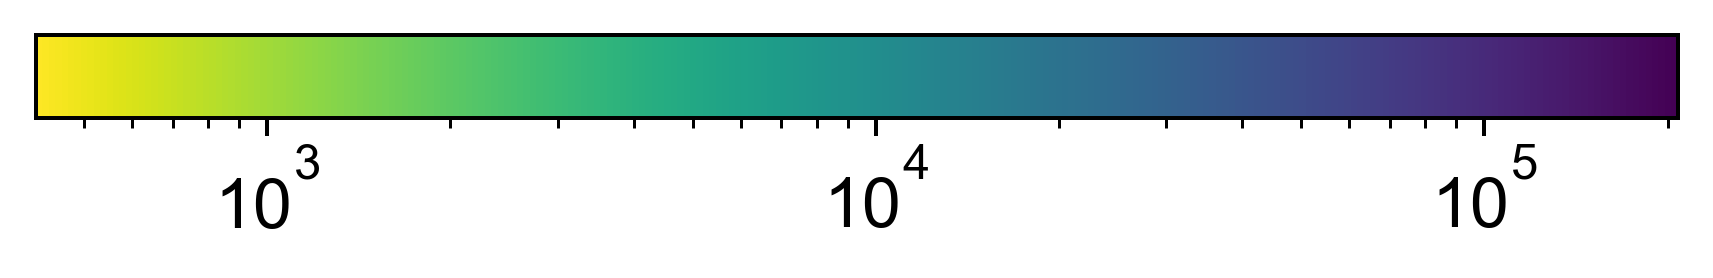

In [ ]:
data = {
    'adult': {
        'ileum': 25663,
        'sigmoid_colon': 7047,
        'caecum': 5235,
        'transverse_colon': 3975,
        'ascending_colon': 2418,
        'appendix': 2325,
        'descending_colon': 897,
        'duodenum': 669,
        'jejunum': 630,
        'rectum': 417
    },
    'fetal': {
        'duodenum': 207781,
        'ileum': 82680,
        'colon': 27289
    },
    'cell_culture': {
        'ileum': 11748,
        'duodenum': 10558
    }
}

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 2))

# Create colormap
vmin = 417  # minimum value
vmax = 207781  # maximum value
norm = LogNorm(vmin=vmin, vmax=vmax)
cmap = plt.cm.viridis_r  # Using viridis colormap

# Create colorbar
cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                 ax=ax,
                 orientation='horizontal')

# Remove the dummy image
ax.remove()

# Function to get hex color for a value
def get_color_for_value(value):
    normalized_value = norm(value)
    rgba = cmap(normalized_value)
    return mcolors.rgb2hex(rgba)

# Print color codes for each data point
print("\nColor codes for each region:")
print("\nAdult samples:")
for region, value in data['adult'].items():
    color = get_color_for_value(value)
    print(f"{region}: {value} cells -> {color}")

print("\nFetal samples:")
for region, value in data['fetal'].items():
    color = get_color_for_value(value)
    print(f"{region}: {value} cells -> {color}")

print("\nCell culture samples:")
for region, value in data['cell_culture'].items():
    color = get_color_for_value(value)
    print(f"{region}: {value} cells -> {color}")
plt.savefig('figures/colormap_cells_per_region.png', dpi=300, bbox_inches='tight')
plt.show()

### Figure 1B

In [86]:
adata.obs['age_group'].value_counts()   

age_group
Unknown               32535
adult & adolescent    16741
Name: count, dtype: int64

In [11]:
adata.obs['age_group'].value_counts()

age_group
second trimester      169491
first trimester       148222
adult & adolescent     49276
cell culture model     22305
Name: count, dtype: int64

In [90]:
adata = adata[~((adata.obs['age_group'] == 'cell culture model') & 
                (~adata.obs['C_scANVI'].isin(['Epithelial', 'Mesenchymal'])))]

In [91]:
mapping = {
    'adult': 'adult & adolescent',
    'child stage': 'adult & adolescent',
    'second trimester': 'second trimester',
    'first trimester': 'first trimester',
    'cell culture model': 'cell culture model'
}

adata.obs['age_group'] = adata.obs['age_group'].map(mapping)

/var/folders/kr/nd4y_1_s34n42lrht8wdh4cr0000gq/T/ipykernel_2435/4055280779.py:9: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


In [12]:
adata.obs['C_scANVI'].value_counts()

C_scANVI
Mesenchymal     185130
Epithelial      110128
Neuronal         21551
T cells          20570
Myeloid          19561
Endothelial      12556
B cells          11110
Plasma cells      8688
Name: count, dtype: int64

In [ ]:
# Define bar properties
bar_height = 0.2  # Controls the thickness of each bar
                 # and spacing between groups

def create_horizontal_bars(ax, data, colors, height=bar_height):
    y = np.arange(len(data.index))
    for i, (condition, color) in enumerate(zip(data.columns, colors)):
        ax.barh(y + i*height, data[condition], height, label=condition, color=color)
    return y

# Calculate proportions
proportions = pd.crosstab(adata.obs['C_scANVI'], adata.obs['age_group'], normalize='columns')

# Color scheme
colors = ['#FF76CE',  # bright pink
                '#E9A8F2',  # light lavender
                '#94FFD8',  # mint green
                '#A3D8FF',  # light sky blue
                '#FFA27F',  # light coral
                '#982B1C',  # bricks color
                '#43766C',  #dark teal
                ]  # pink, purple, light green, light blue

# Create figure
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111)

# Separate large and small proportions
threshold = 0.1  # Adjust this threshold based on your data
max_vals = proportions.max(axis=1)
large_props = proportions[max_vals >= threshold]
small_props = proportions[max_vals < threshold]

# Plot large proportions in main axis
y = create_horizontal_bars(ax, large_props, colors)
ax.set_yticks(y + bar_height*1.5)
ax.set_yticklabels(large_props.index, ha='right')
ax.set_xlabel('Proportion')
ax.set_title('Cell Type Proportions by Condition')

# Add grid lines
ax.grid(True, axis='x', alpha=0.3)

# Create inset axes for small proportions
# Adjust these values to position the inset where you want it
ax_inset = ax.inset_axes([0.6, 0.6, 0.35, 0.35])

# Plot small proportions in inset
y_small = create_horizontal_bars(ax_inset, small_props, colors)
ax_inset.set_yticks(y_small + bar_height*1.5)
ax_inset.set_yticklabels(small_props.index, ha='right')
ax_inset.set_title('Small Populations')
ax_inset.grid(True, axis='x', alpha=0.3)

# Add legend outside the plot
ax.legend(title='Conditions', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig('figures/cell_type_proportions.png', dpi=300, bbox_inches='tight')

plt.show()

First few rows of the counts table:
age_group    adult & adolescent  cell culture model  first trimester  \
C_scANVI                                                               
B cells                    8443                   0              470   
Endothelial                1184                   0             6610   
Epithelial                19108               19294            43127   
Mesenchymal                3737                 861            75767   
Myeloid                    1450                   0             5194   

age_group    second trimester  
C_scANVI                       
B cells                  2135  
Endothelial              4651  
Epithelial              28599  
Mesenchymal            104765  
Myeloid                 12447  

Threshold for separating large and small populations: 11627.0

Number of large populations: 4
Number of small populations: 4


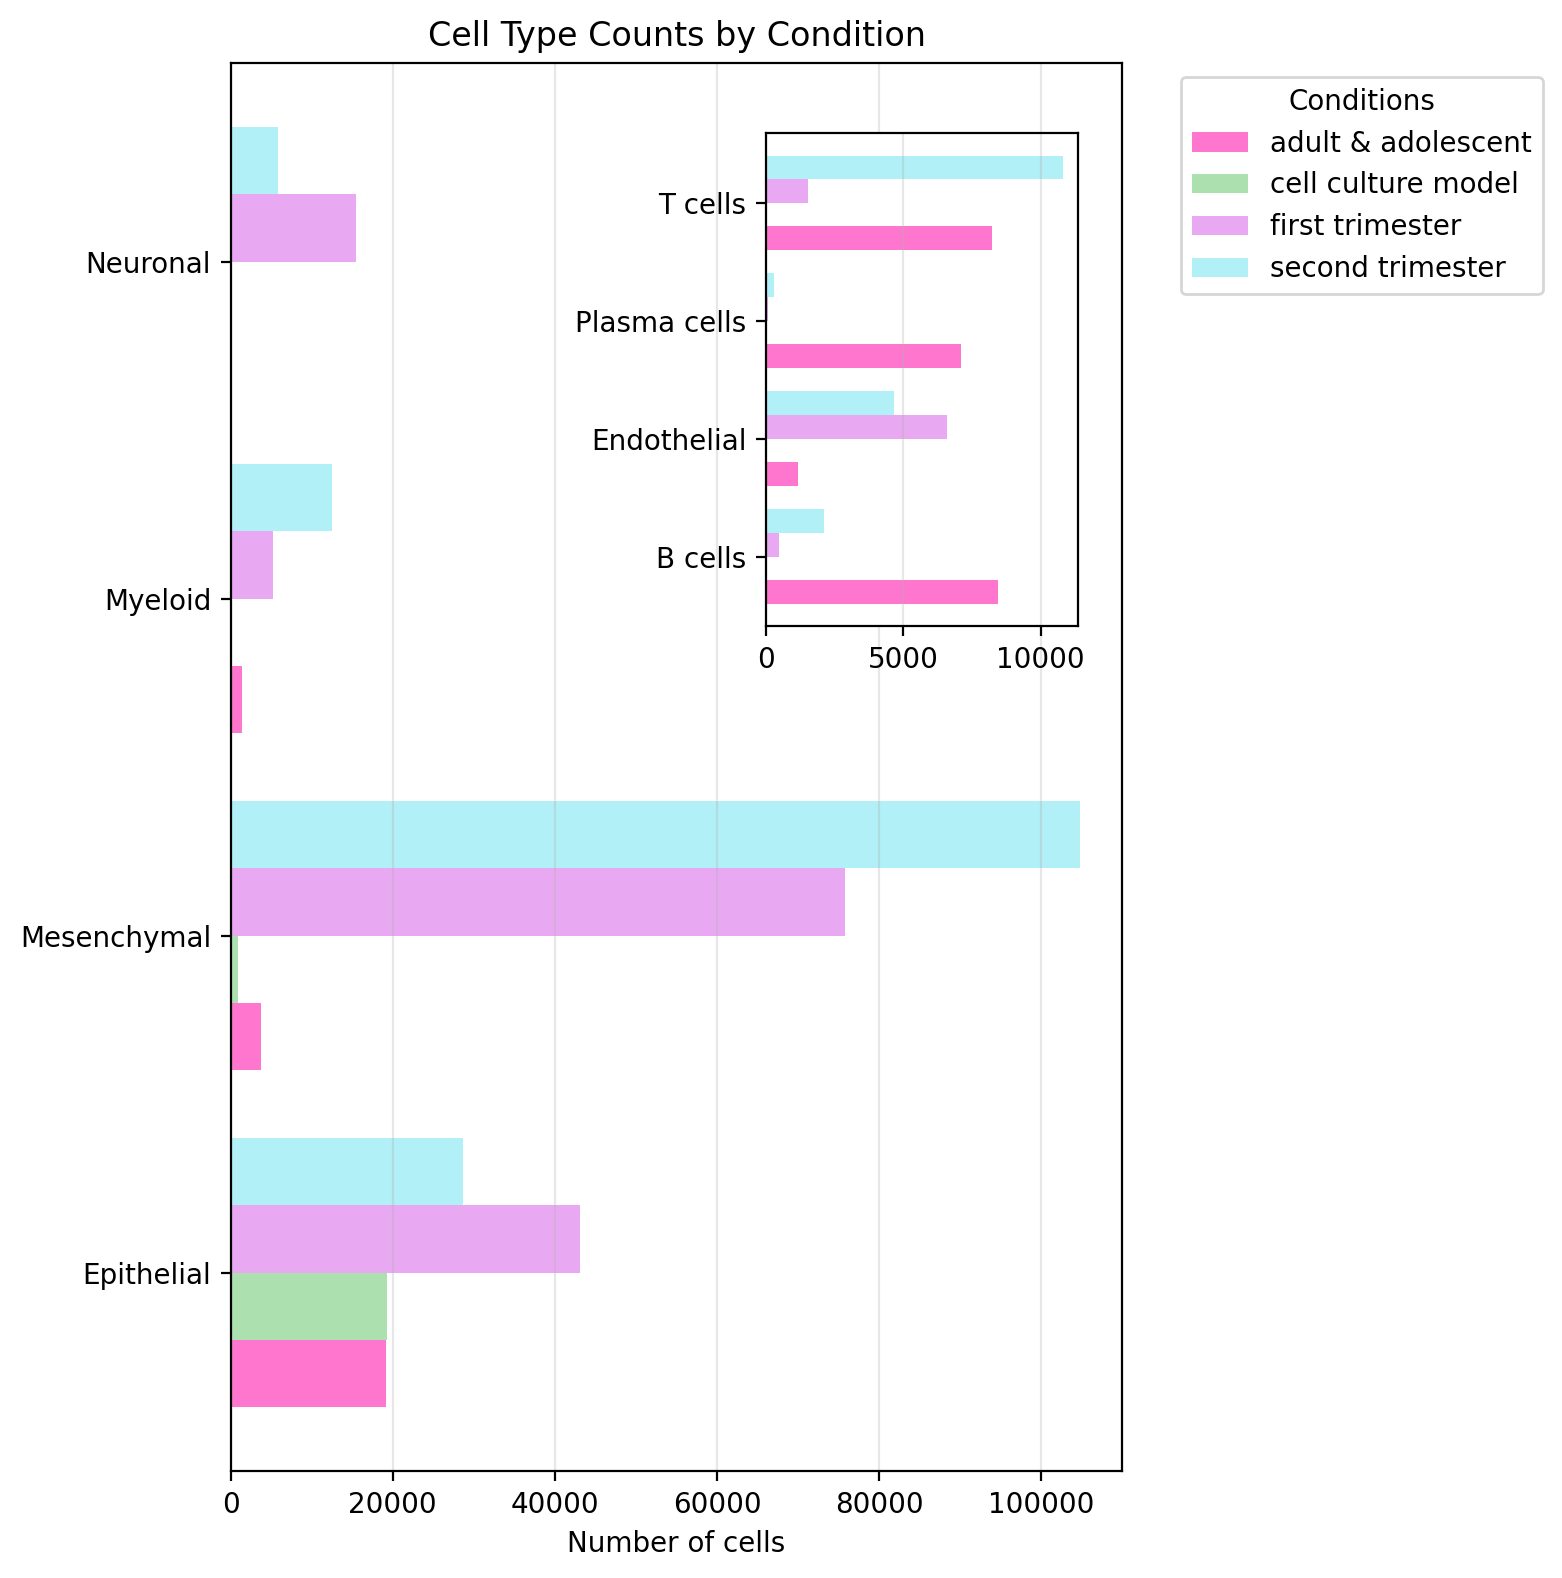

In [97]:
bar_height = 0.2  # Controls the thickness of each bar and spacing between groups

def create_horizontal_bars(ax, data, colors, height=bar_height):
    y = np.arange(len(data.index))
    for i, (condition, color) in enumerate(zip(data.columns, colors)):
        ax.barh(y + i*height, data[condition], height, label=condition, color=color)
    return y

# Calculate cell counts from AnnData object
counts = pd.crosstab(adata.obs['C_scANVI'], adata.obs['age_group'])

# Print the first few rows to verify the data
print("First few rows of the counts table:")
print(counts.head())

# Create figure
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111)

# Color scheme
colors = ['#FF76CE',  # bright pink
                '#ACE1AF',  # mint green
                '#E9A8F2',  # light lavender
                '#B1F0F7',  # light sky blue
                ]

# Separate large and small counts
threshold = np.median(counts.max(axis=1))  # Adjust threshold based on counts
print(f"\nThreshold for separating large and small populations: {threshold}")
max_vals = counts.max(axis=1)
large_counts = counts[max_vals >= threshold]
small_counts = counts[max_vals < threshold]

print(f"\nNumber of large populations: {len(large_counts)}")
print(f"Number of small populations: {len(small_counts)}")

# Plot large counts in main axis
y = create_horizontal_bars(ax, large_counts, colors)
ax.set_yticks(y + bar_height*1.5)
ax.set_yticklabels(large_counts.index, ha='right')
ax.set_xlabel('Number of cells')
ax.set_title('Cell Type Counts by Condition')

# Add grid lines
ax.grid(True, axis='x', alpha=0.3)

# Create inset axes for small populations
ax_inset = ax.inset_axes([0.6, 0.6, 0.35, 0.35])

# Plot small counts in inset
y_small = create_horizontal_bars(ax_inset, small_counts, colors)
ax_inset.set_yticks(y_small + bar_height*1.5)
ax_inset.set_yticklabels(small_counts.index, ha='right')
ax_inset.grid(True, axis='x', alpha=0.3)

# Add legend outside the plot
ax.legend(title='Conditions', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig('/Users/annamaguza/Desktop/Repos/Fetal_stem_cells_analysis/2_celltype_annotation/figures/cell_type_proportions_cell_number.png', dpi=300, bbox_inches='tight')

plt.show()

## Figure 1C

In [7]:
adata = adata_log.copy()

In [8]:
mapping = {
    'adult': 'adult & adolescent',
    'child stage': 'adult & adolescent',
    'second trimester': 'second trimester',
    'first trimester': 'first trimester',
    'cell culture model': 'cell culture model'
}

adata.obs['age_group'] = adata.obs['age_group'].map(mapping)

In [35]:
region_map = {
    'duodenum': 'small intestine',
    'ileum': 'small intestine',
    'small intestine': 'small intestine',
    'terminal ileum': 'small intestine',
    'jejunum': 'small intestine',
    'sigmoid colon': 'large intestine',
    'caecum': 'large intestine',
    'ascending colon': 'large intestine',
    'transverse colon': 'large intestine',
    'large intestine': 'large intestine',
    'descending colon': 'large intestine',
    'appendix': 'large intestine',
    'colon': 'large intestine',
    'rectum': 'large intestine'
}

adata.obs['gut_region'] = adata.obs['organism_part'].map(region_map)

In [39]:
adata.obs['cell_states'] = adata.obs['cell_states'].astype(str)
adata.obs['gut_region'] = adata.obs['gut_region'].astype(str)
adata.obs['cell_states_and_gut_region'] = adata.obs['cell_states'] + '_' + adata.obs['gut_region']
adata.obs['cell_states_and_gut_region'].value_counts()

cell_states_and_gut_region
Enterocyte_small intestine                    26785
Proximal progenitor_small intestine           21145
TA_small intestine                            12624
Stem cells_small intestine                    11614
Colonocyte_small intestine                     9596
Proximal progenitor_large intestine            5159
BEST4+ epithelial_small intestine              3677
TA_large intestine                             2519
BEST4+ epithelial_large intestine              2072
Enterocyte_large intestine                     1966
Stem cells_large intestine                     1881
Colonocyte_large intestine                     1819
Goblet cell_small intestine                    1589
immature Goblet cell_small intestine           1403
mature Goblet cell_small intestine             1268
EECs_small intestine                           1223
Goblet cell_large intestine                     706
D cells (SST+)_small intestine                  417
I cells (CCK+)_small intestine       

In [40]:
def calculate_expression_stats(adata, genes, groupby='age_group', cell_type_col='cell_states_and_gut_region'):
    """Calculate percentage of expressing cells and mean expression for each group."""
    results = []
    
    # Ensure we're working with dense array
    if scipy.sparse.issparse(adata.X):
        expr_matrix = adata.X.toarray()
    else:
        expr_matrix = adata.X
    
    for group in adata.obs[groupby].unique():
        for cell_type in ['Stem cells_small intestine', 'Stem cells_large intestine']:
            mask = (adata.obs[groupby] == group) & (adata.obs[cell_type_col] == cell_type)
            if np.any(mask):  # Check if we have any cells in this group
                for gene in genes:
                    if gene in adata.var_names:
                        # Get gene index
                        gene_idx = adata.var_names.get_loc(gene)
                        
                        # Get expression values for this gene
                        expr = expr_matrix[mask, gene_idx]
                        
                        # Calculate percentage of expressing cells (> 0)
                        pct = np.mean(expr > 0) * 100
                        
                        # Calculate mean expression in expressing cells
                        mean_expr = np.mean(expr[expr > 0]) if np.any(expr > 0) else 0
                        
                        results.append({
                            'group': group,
                            'cell_type': cell_type,
                            'gene': gene,
                            'pct_expressed': pct,
                            'mean_expression': mean_expr
                        })
    
    return pd.DataFrame(results)

In [41]:
# Assuming we have genes grouped by categories
gene_categories = {
    'Stem cells markers': ['LGR5', 'ASCL2', 'OLFM4', 'SMOC2', 'RGMB'],
    'Early stem markers': ['GATA4', 'VTN', 'ONECUT2']
}

# Flatten gene list
all_genes = [gene for genes in gene_categories.values() for gene in genes]

In [42]:
stats_df = calculate_expression_stats(adata, all_genes)

In [ ]:
stats_df

/var/folders/kr/nd4y_1_s34n42lrht8wdh4cr0000gq/T/ipykernel_2435/884719853.py:118: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations


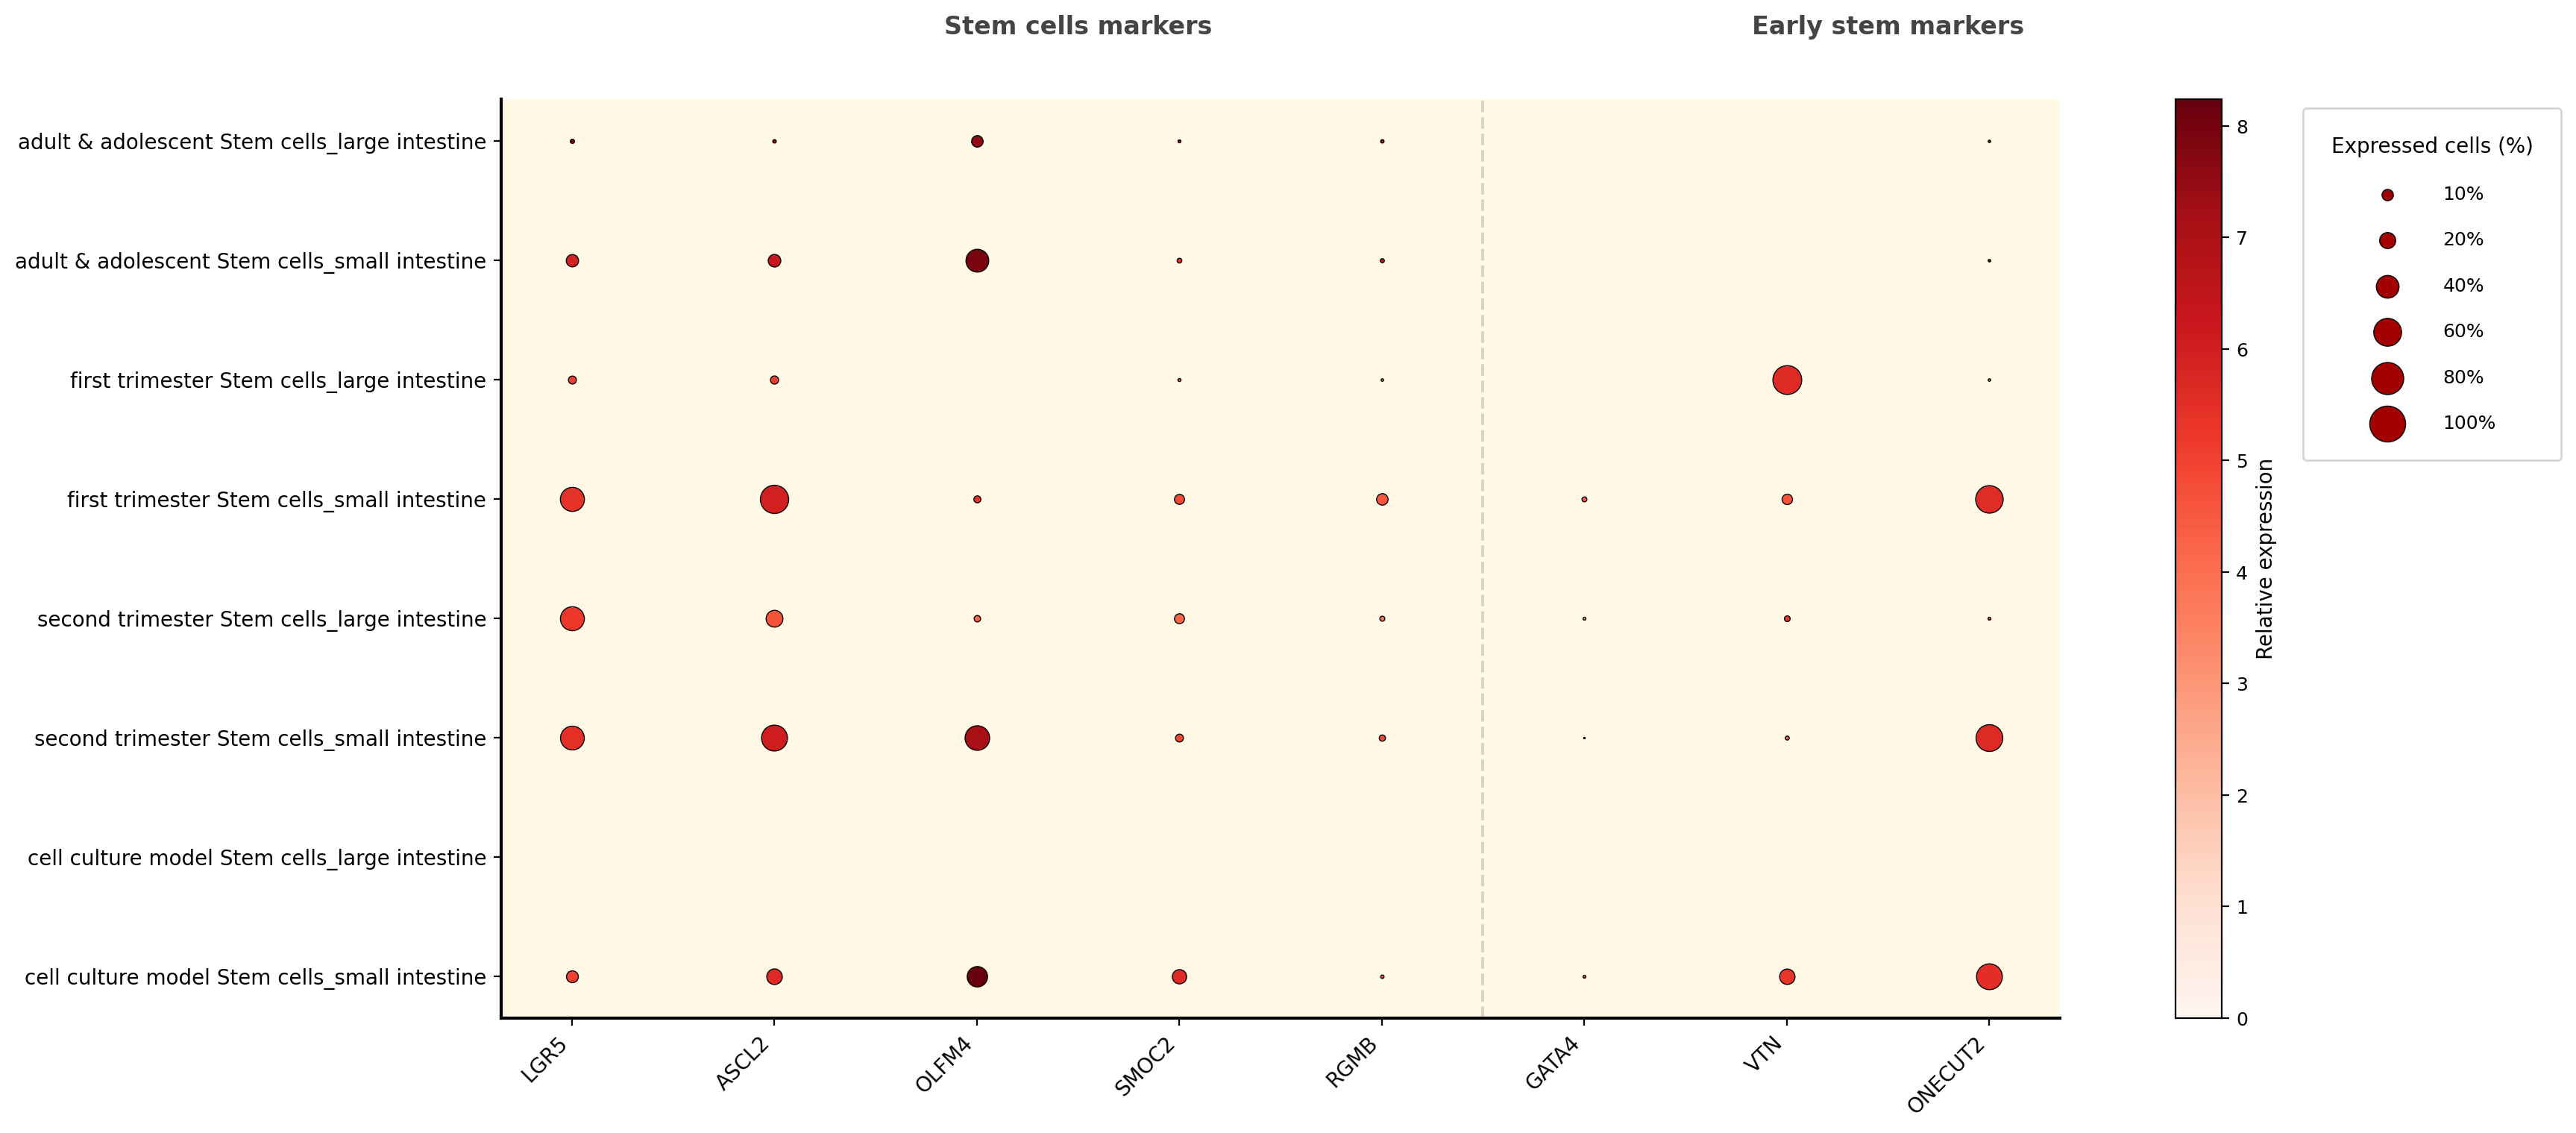

In [ ]:
# Create the plot with explicit axes
plt.style.use('default')
fig = plt.figure(figsize=(15, 8))
gs = plt.GridSpec(1, 20)
ax = fig.add_subplot(gs[:, :18])  # Main plot
cax = fig.add_subplot(gs[:, 19])  # Colorbar axis

# Set background colors
ax.set_facecolor('#FFF9E6')  # Light yellow background
fig.patch.set_facecolor('white')

# Set up the grid for the plot
groups = adata.obs['age_group'].unique()
cell_types = ['Stem cells_small intestine', 'Stem cells_large intestine']
genes = all_genes

# Plot dots
for i, group in enumerate(groups):
    for j, cell_type in enumerate(cell_types):
        for k, gene in enumerate(genes):
            data = stats_df[
                (stats_df['group'] == group) &
                (stats_df['cell_type'] == cell_type) &
                (stats_df['gene'] == gene)
            ]
            
            if not data.empty:
                size = data['pct_expressed'].iloc[0]
                color = data['mean_expression'].iloc[0]
                
                ax.scatter(
                    k, 
                    i*2 + j,
                    s=size*3,  # Reduced base size multiplier
                    c=[color],
                    cmap='Reds',
                    vmin=0,
                    vmax=stats_df['mean_expression'].max(),
                    edgecolor='black',
                    linewidth=0.5
                )

# Customize the plot
ax.set_yticks(
    np.arange(len(groups)*2),
    [f"{group} {cell_type}" for group in groups for cell_type in cell_types],
    fontsize=10
)

ax.set_xticks(
    range(len(all_genes)),
    all_genes,
    rotation=45,
    ha='right',
    fontsize=10
)

# Add spines styling
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    
# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add gene category labels with enhanced styling
category_positions = []
current_pos = 0
for category, genes in gene_categories.items():
    category_positions.append((current_pos + len(genes)/2, category))
    current_pos += len(genes)
    if current_pos < len(all_genes):
        ax.axvline(x=current_pos-0.5, color='gray', linestyle='--', alpha=0.3)

for pos, category in category_positions:
    ax.text(pos, ax.get_ylim()[1] + 0.5, category, 
            ha='center', va='bottom', 
            fontsize=12, fontweight='bold', 
            color='#444444')

# Modified legend for dot size with increased spacing
sizes = [10, 20, 40, 60, 80, 100]
legend_elements = []
for s in sizes:
    # Create scatter plot with adjusted size
    scatter = plt.scatter([], [], 
                         s=s*3,  # Reduced base size multiplier
                         c='#A30000', 
                         label=f'{s}%', 
                         edgecolor='black', 
                         linewidth=0.5)
    legend_elements.append(scatter)

# Create legend with increased spacing
legend = ax.legend(handles=legend_elements, 
                  title='Expressed cells (%)', 
                  bbox_to_anchor=(1.15, 1), 
                  loc='upper left',
                  title_fontsize=10,
                  fontsize=9,
                  labelspacing=1.5,  # Increased spacing between legend items
                  handletextpad=2,   # Increased spacing between dot and text
                  borderpad=1.5)     # Increased padding inside legend

# Add colorbar for expression levels with modified styling
sm = plt.cm.ScalarMappable(cmap='Reds', 
                          norm=plt.Normalize(vmin=0, 
                                           vmax=stats_df['mean_expression'].max()))

# Modified colorbar with reduced width
cbar = plt.colorbar(sm, cax=cax, label='Relative expression')
cbar.ax.tick_params(labelsize=9)
cbar.ax.set_ylabel('Relative expression', fontsize=10)

# Adjust colorbar width
cax.set_box_aspect(20)  # Make colorbar more narrow

plt.tight_layout()

# Save the plot
plt.savefig('figures/Figure1C_stem_cell_markers_expression_gene_expression_dotplot_full.png', dpi=300, bbox_inches='tight')

plt.show()

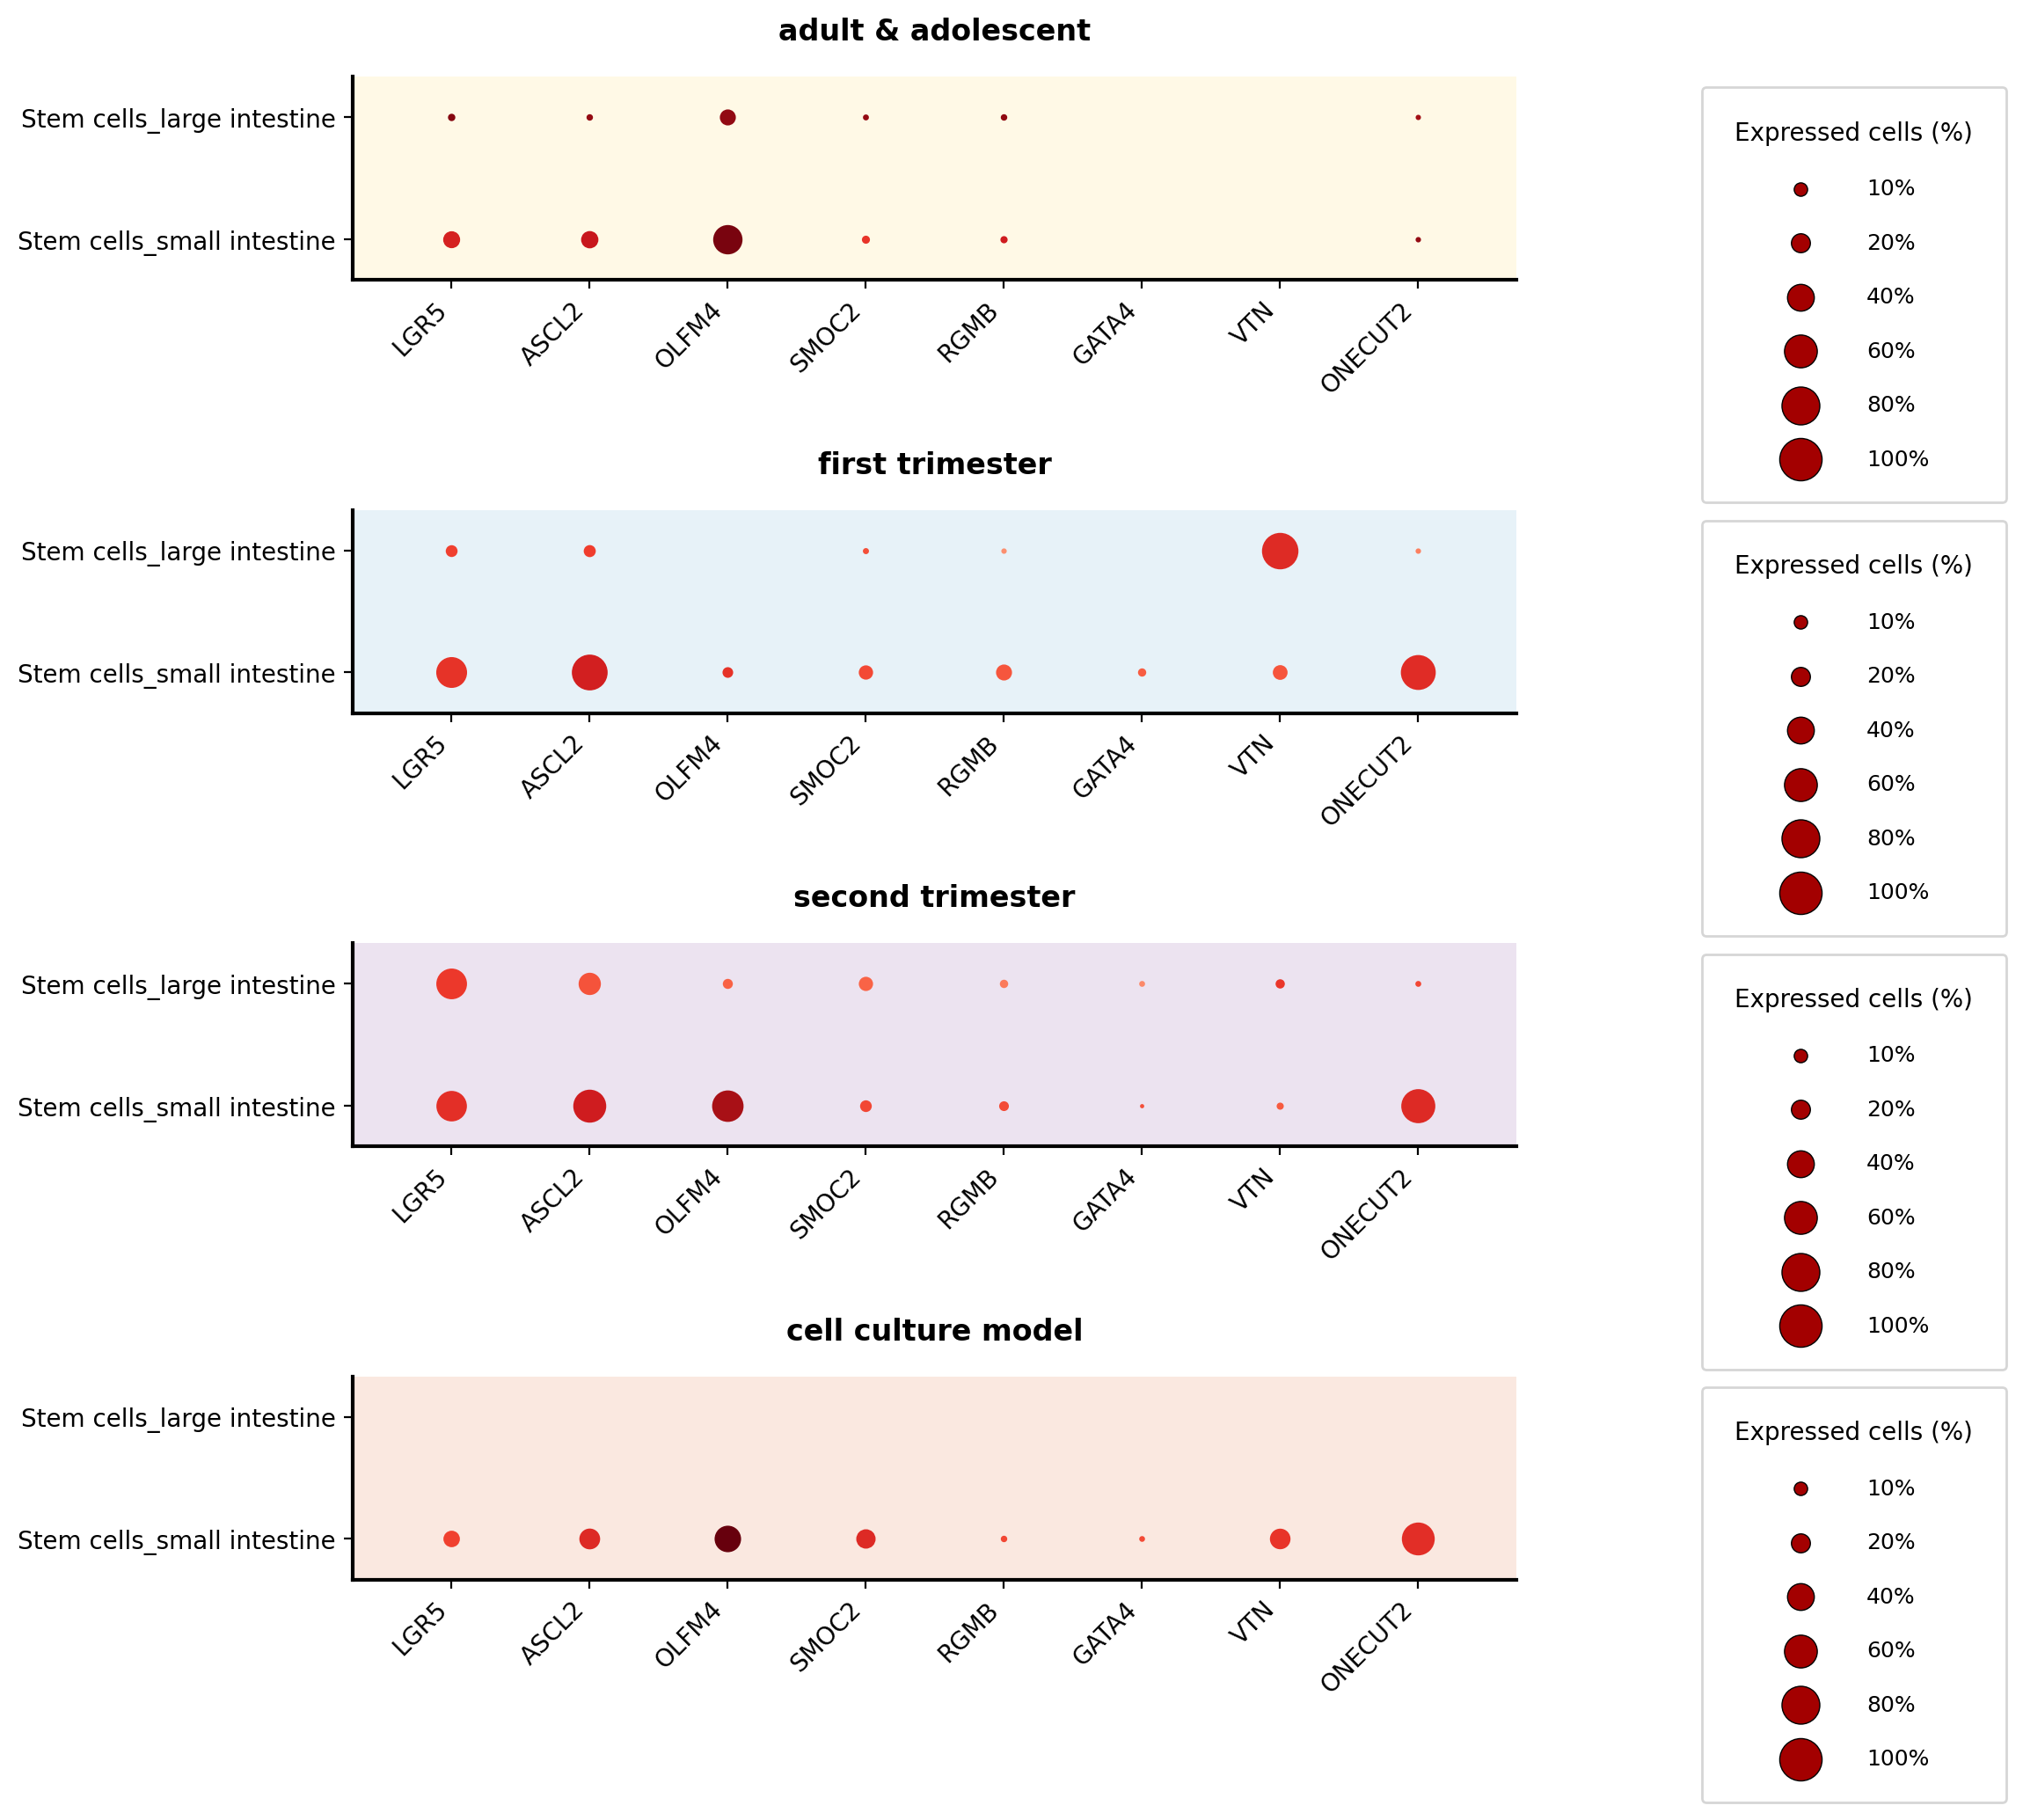

In [83]:
plt.style.use('default')
fig = plt.figure(figsize=(12, 10))  

# Define background colors for each plot
bg_colors = {
    'adult & adolescent': '#FFF9E6',
    'first trimester': '#e7f2f8',
    'second trimester': '#ece3f0',
    'cell culture model': '#fae8e0'
}

# Create subplot for each group
groups = ['adult & adolescent', 'first trimester', 'second trimester', 'cell culture model']
cell_types = ['Stem cells_small intestine', 'Stem cells_large intestine']

for idx, group in enumerate(groups, 1):
    ax = plt.subplot(4, 1, idx)
    
    # Set background color
    ax.set_facecolor(bg_colors[group])
    
    # Plot dots for this group
    for j, cell_type in enumerate(cell_types):
        for k, gene in enumerate(all_genes):
            data = stats_df[
                (stats_df['group'] == group) &
                (stats_df['cell_type'] == cell_type) &
                (stats_df['gene'] == gene)
            ]
            
            if not data.empty:
                size = data['pct_expressed'].iloc[0]
                color = data['mean_expression'].iloc[0]
                
                # Use compressed x-coordinates
                ax.scatter(
                    k * 0.7,  # Multiply by 0.7 to reduce horizontal spacing
                    j*0.3,
                    s=size*3,
                    c=[color],
                    cmap='Reds',
                    vmin=0,
                    vmax=stats_df['mean_expression'].max(),
                    edgecolor=None,
                    linewidth=1
                )
    
    # Adjust y-ticks to match new spacing
    ax.set_yticks(
        [i*0.3 for i in range(len(cell_types))],
        cell_types,
        fontsize=10
    )
    
    # Reduce top margin by adjusting y-axis limits
    ax.set_ylim(-0.1, 0.4)  # Adjusted from (-0.2, 0.7) to reduce top space
    
    # Adjust x-ticks to match compressed spacing
    ax.set_xticks(
        [k * 0.7 for k in range(len(all_genes))],  # Match the compressed x-coordinates
        all_genes,
        rotation=45,
        ha='right',
        fontsize=10
    )
    
    # Add spines styling
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Set x-axis limits to match compressed spacing
    ax.set_xlim(-0.5, (len(all_genes) - 1) * 0.7 + 0.5)
    
    # Add title with reduced padding
    ax.set_title(group, fontsize=12, fontweight='bold', pad=15)  # Reduced pad from 20 to 15

    # Modified legend for dot size with increased spacing
    sizes = [10, 20, 40, 60, 80, 100]
    legend_elements = []
    for s in sizes:
        scatter = plt.scatter([], [], 
                            s=s*3,
                            c='#A30000', 
                            label=f'{s}%', 
                            edgecolor='black', 
                            linewidth=0.5)
        legend_elements.append(scatter)

    # Create legend with increased spacing
    legend = ax.legend(handles=legend_elements, 
                    title='Expressed cells (%)', 
                    bbox_to_anchor=(1.15, 1), 
                    loc='upper left',
                    title_fontsize=10,
                    fontsize=9,
                    labelspacing=1.5,
                    handletextpad=2,
                    borderpad=1.5)

# Adjust layout
plt.tight_layout()

# Save the plots
plt.savefig('figures/Figure1C_stem_cell_markers_expression_gene_expression_dotplot_subplots.png', dpi=300, bbox_inches='tight')
#plt.savefig('gene_expression_dotplots.svg', format='svg', bbox_inches='tight')

plt.show()